## Optional Pandas Exercise (Due March 19, 2026)


# Diving deeper into Vegetables and Dry Pulses
Using the same dataset as lecture 6 (https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229), please create the following notebook (each bullet point should be a code cell in Google Colab):

*  Import the data and store it in a variable
*  Clean and filter the data: only keep rows that deal in **Thousand dollars** (we want a financial analysis), and only the rows specific to **Import**s. Remove countries that are marked as **World**
*   Let's analyse the countries the US imports from. Create a bar graph that shows the number of countries we import from every year (hint: unique() returns the unique values as a list. nunique() returns the number of unique values). After that, display all the countries (as a list) that we imported from in 2024
*   Let's see what we spend the most on imports. Find out which commodity we spent the most on in 2025. And in 2024?
*   Which country did we import the most from in 2025, in dollar amount?  And in 2017?
*   Look back at our most imported commodity (answered above). Plot a line graph that shows the amount spent on imports of this commodity by year. What do you notice?
*   For this same commodity, take a look at the imports made by **MonthNumber**. Plot a bar graph to see how much was spent on imports every month of the year. Does this match what you could expect?
*   We can see if monthly differences are due to lack of US supply or a price increase. Plot the same graph as above, but for **Thousand pounds** and not **Thousand** dollars (hint: you'll need to repeat some steps done above, specifically in the the cleaning and filtering section). Doing a visual analysis of the two bar graphs, does the US spend more on imports of the top commodity due to an increase in demand or an increase in price?






In [ ]:
# Import the data and store it in a variable
import pandas as pd

url = "https://www.ers.usda.gov/media/5628/vegetables-and-dry-pulses-trade-data.csv?v=74229"

df = pd.read_csv(url)

In [ ]:
# df
# df.describe()
# df.columns

,Trade,GeographicDesc,Year,MonthNumber,MarketYear,Group,Subgroup,MarketSegment,CommodityName,CommodityDetail,UnitType,UnitDesc,Amount
0,Import,Albania,2025,11,2025/26,Dry pulses,Dried beans,Dried,White beans,Unspecified,Value,Thousand dollars,14.87600
1,Import,Albania,2025,11,2025/26,Dry pulses,Dried beans,Dried,White beans,Unspecified,Volume,Thousand pounds,14.25950
2,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Dark red,Value,Thousand dollars,54.05200
3,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Dark red,Volume,Thousand pounds,201.29086
4,Import,Argentina,2025,11,2025/26,Dry pulses,Dried beans,Dried,Kidney beans,Unspecified,Value,Thousand dollars,48.00600
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700388,Export,World,2017,1,2017,Vegetables,Vegetables,Juice,"Vegetables, other",Other,Volume,Thousand gallons,700.36462
700389,Export,World,2017,1,2017,Vegetables,Vegetables,Juice,"Vegetables, other",Other,Unit value,Dollars per gallon,5.57453
700390,Export,World,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,"Vegetables, other",Other,Value,Thousand dollars,12063.12400
700391,Export,World,2017,1,2017,Vegetables,Vegetables,Prepared or preserved,"Vegetables, other",Other,Volume,Thousand pounds,17945.95663


In [ ]:
# Clean and filter the data

# Filter to only keep rows that deal in Thousand dollars (we want a financial analysis), and only the rows specific to Imports.
row_count_before = len(df)

is_dollars = (df["UnitDesc"] == "Thousand dollars") # filter for dollars
is_import = (df["Trade"] == "Import") # filter for imports

df_imports_in_dollars = df[is_dollars & is_import]

# df_imports_in_dollars = df[(df["UnitDesc"] == "Thousand dollars") & (df["Trade"] == "Import")]

row_count_after = len(df_imports_in_dollars)
print("This many Unit,Trade rows were filtered out: " + str(row_count_after - row_count_before))

# Remove countries that are marked as World
row_count_before = len(df_imports_in_dollars)

# Use a filter to create a "subset" DataFrame containing all of the rows from the df_imports_in_dollars where the GeographicDesc column has any value except "World"
is_not_World = (df_imports_in_dollars['GeographicDesc'] != "World")
df_dollars_by_country = df_imports_in_dollars[is_not_World]

# df_dollars_by_country = df_imports_in_dollars[(df_imports_in_dollars['GeographicDesc'] != "World")]

row_count_after = len(df_dollars_by_country)
print("This many World rows were filtered out: " + str(row_count_after - row_count_before))

# An alternative way to remove the "World" rows using "drop"
# get the indices of all the rows where GeographicDesc = "World"
indices_to_drop = df_imports_in_dollars[df_imports_in_dollars['GeographicDesc'] == 'World'].index

row_count_before = len(df_imports_in_dollars)

df_dollars_by_country = df_imports_in_dollars.drop(indices_to_drop, axis=0)

row_count_after = len(df_dollars_by_country)
print("This many World rows were dropped: " + str(row_count_after - row_count_before))

# Rename columns
renaming_map = {"GeographicDesc": "Country"}

df_dollars_by_country.rename(columns=renaming_map, inplace=True)
print(df_dollars_by_country.columns)

This many Unit,Trade rows were filtered out: -539020
This many World rows were filtered out: -18602
This many World rows were dropped: -18602
Index(['Trade', 'Country', 'Year', 'MonthNumber', 'MarketYear', 'Group',
       'Subgroup', 'MarketSegment', 'CommodityName', 'CommodityDetail',
       'UnitType', 'UnitDesc', 'Amount'],
      dtype='object')


We imported from 137 countries in 2024. Here is the list:
['Afghanistan' 'Albania' 'Argentina' 'Australia' 'Belgium' 'Brazil'
 'Cameroon' 'Canada' 'China' 'Colombia' 'Costa Rica' 'Denmark' 'Egypt'
 'El Salvador' 'Ethiopia' 'France' 'Ghana' 'Greece' 'Guatemala' 'Honduras'
 'Hong Kong' 'Hungary' 'India' 'Israel' 'Italy' 'Jordan' 'Kenya' 'Lebanon'
 'Madagascar (Malagasy)' 'Mexico' 'Burma' 'New Zealand' 'Nicaragua'
 'Nigeria' 'Paraguay' 'Peru' 'Poland' 'Portugal' 'South Africa' 'Serbia'
 'South Korea' 'Taiwan' 'Tanzania' 'Thailand' 'Trinidad and Tobago'
 'Turkey' 'Ukraine' 'United Arab Emirates' 'United Kingdom' 'Vietnam'
 'Armenia' 'Austria' 'Azerbaijan' 'Bangladesh' 'Bosnia-Hercegovina'
 'Bulgaria' 'Cambodia' 'Chile' 'Croatia' 'Czech Republic' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Fiji' 'Germany' 'Haiti' 'Indonesia'
 'Iran' 'Iraq' 'Ireland' 'Ivory Coast' 'Jamaica' 'Japan' 'Kosovo' 'Latvia'
 'Lithuania' 'Macedonia (Skopje)' 'Malawi' 'Malaysia' 'Mayotte'
 'Micronesia, Federated State

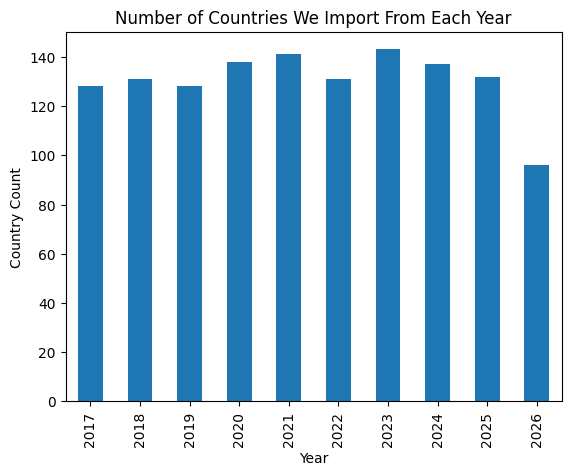

In [ ]:
# Analyse the countries the US imports from.
# Create a bar graph that shows the number of countries we import from every year (hint: unique() returns the unique values as a list. nunique() returns the number of unique values).

# list of unique countries
country_list = df_dollars_by_country['Country'].unique()
# print(country_list)
country_count = df_dollars_by_country['Country'].nunique()
# print(country_count)

# group the data by Year, aggregating the number of unique countries
df_grouped = df_dollars_by_country.groupby(["Year"])["Country"].nunique()
# print (df_grouped)
bar_graph = df_grouped.plot(kind="bar")
bar_graph.set_ylabel("Country Count")
bar_graph.set_title("Number of Countries We Import From Each Year")

# Display all the countries (as a list) that we imported from in 2024
df_imports_2024 = df_dollars_by_country[df_dollars_by_country["Year"] == 2024]
number_of_countries = df_imports_2024["Country"].nunique()

print ("We imported from " + str(number_of_countries) + " countries in 2024. Here is the list:")

print (df_imports_2024["Country"].unique())

# added my own exercise to print the same countries in a numbered vertical list (one per line), iterating through the list with a for loop
df_2024_unique_countries_list = df_imports_2024["Country"].unique()
i = 1
for country in df_2024_unique_countries_list:
  print(str(i) + ". " + country)
  i += 1


In [ ]:
# Find out which commodity we spent the most on in 2025. And in 2024?
# Group the DataFrame by Year and Commodity, aggregate the Amount
df_grouped = df_dollars_by_country.groupby(["Year", "CommodityName"])['Amount'].sum()
# print(df_grouped)
# print(type(df_grouped)) # this is a Series with a MultiIndex
# convert the groupby series into a DataFrame so I can sort by the summed amount for each commodity
df_grouped_table = df_grouped.reset_index()
# print(type(df_grouped_table)) # <class 'pandas.core.frame.DataFrame'>
df_grouped_table_sorted = df_grouped_table.sort_values(['Year','Amount'], ascending=[False,False])
print ("The commodity we spent the most on in 2025 is:")
print (df_grouped_table_sorted[df_grouped_table_sorted["Year"] == 2025].head(1))
print ("The commodity we spent the most on in 2024 is:")
print (df_grouped_table_sorted[df_grouped_table_sorted["Year"] == 2024].head(1))

# to get the top commodity for every year in the DataFrame, group the sorted table by Year (without any aggregation) and get the first row in each group
print ("Here is a list of the commodity we spent the most on in each Year:")
print(df_grouped_table_sorted.groupby(["Year"]).head(1))


The commodity we spent the most on in 2025 is:
     Year CommodityName       Amount
470  2025      Tomatoes  3690460.138
The commodity we spent the most on in 2024 is:
     Year CommodityName     Amount
416  2024      Tomatoes  4536362.8
Here is a list of the commodity we spent the most on in each Year:
     Year CommodityName       Amount
523  2026      Tomatoes   288731.295
470  2025      Tomatoes  3690460.138
416  2024      Tomatoes  4536362.800
363  2023      Tomatoes  3823832.790
310  2022      Tomatoes  3369809.610
256  2021      Tomatoes  3171775.187
204  2020      Tomatoes  3137889.620
152  2019      Tomatoes  2557223.484
100  2018      Tomatoes  2625642.052
48   2017      Tomatoes  2401455.907


In [ ]:
# Which country did we import the most from in 2025, in dollar amount? And in 2017?

df_grouped = df_dollars_by_country.groupby(["Year", "Country"])['Amount'].sum()
df_grouped_table = df_grouped.reset_index()
df_grouped_table_sorted = df_grouped_table.sort_values(['Year','Amount'], ascending=[False,False])
print ("The country we imported the most from in 2025, in dollar amount is:")
print (df_grouped_table_sorted[df_grouped_table_sorted["Year"] == 2025].head(1))
print ("The country we imported the most from in 2017, in dollar amount is:")
print (df_grouped_table_sorted[df_grouped_table_sorted["Year"] == 2017].head(1))

# to get the top country for every year in the DataFrame, group the sorted table by Year (without any aggregation) and get the first row in each group
print ("Here is a list of the country we imported the most from in each Year, in dollar amount:")
print(df_grouped_table_sorted.groupby(["Year"]).head(1))


The country we imported the most from in 2025, in dollar amount is:
      Year Country       Amount
1152  2025  Mexico  8738887.924
The country we imported the most from in 2017, in dollar amount is:
    Year Country       Amount
71  2017  Mexico  6321882.325
Here is a list of the country we imported the most from in each Year, in dollar amount:
      Year Country        Amount
1263  2026  Mexico  9.046440e+05
1152  2025  Mexico  8.738888e+06
1018  2024  Mexico  1.061691e+07
879   2023  Mexico  9.862676e+06
742   2022  Mexico  9.209872e+06
605   2021  Mexico  8.624996e+06
466   2020  Mexico  8.181985e+06
332   2019  Mexico  7.248476e+06
200   2018  Mexico  6.784996e+06
71    2017  Mexico  6.321882e+06


<class 'pandas.core.frame.DataFrame'>
     Year CommodityName       Amount
48   2017      Tomatoes  2401455.907
100  2018      Tomatoes  2625642.052
152  2019      Tomatoes  2557223.484
204  2020      Tomatoes  3137889.620
256  2021      Tomatoes  3171775.187
310  2022      Tomatoes  3369809.610
363  2023      Tomatoes  3823832.790
416  2024      Tomatoes  4536362.800
470  2025      Tomatoes  3690460.138
523  2026      Tomatoes   288731.295
This graph shows that import spending on Tomatoes generally increased from 2017 to 2024 when it peaked.
It seems to show a sharp decline in the current year (2026);
However, that is probably misleading because we are only in March so it doesn't make sense to compare it with other full year values.


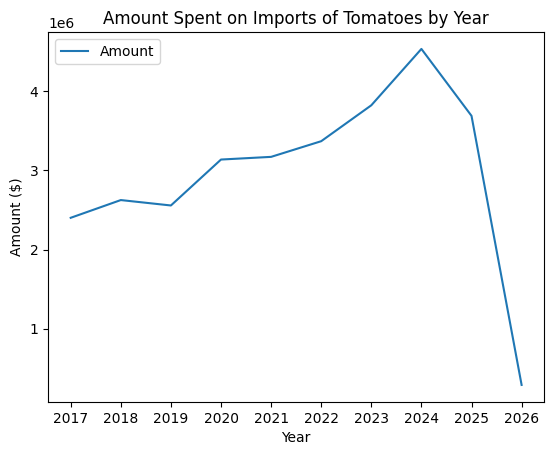

In [ ]:
# Plot a line graph that shows the amount spent on imports of the most imported commodity (Tomatoes) by year. What do you notice?

df_grouped = df_dollars_by_country.groupby(["Year", "CommodityName"])['Amount'].sum()
df_grouped_table = df_grouped.reset_index()
print(type(df_grouped_table))
df_tomatoes = df_grouped_table[(df_grouped_table['CommodityName'] == 'Tomatoes')]
# Make sure the data is sorted by year before graphing
df_tomatoes.sort_values("Year")
print(df_tomatoes)
line_graph = df_tomatoes.plot(x='Year', y='Amount', kind='line')
line_graph.set_xticks(df_tomatoes["Year"])
line_graph.set_xlabel("Year")
line_graph.set_ylabel("Amount ($)")
line_graph.set_title("Amount Spent on Imports of Tomatoes by Year")
print ("This graph shows that import spending on Tomatoes generally increased from 2017 to 2024 when it peaked." + "\n" + "It seems to show a sharp decline in the current year (2026);" + "\n" + "However, that is probably misleading because we are only in March so it doesn't make sense to compare it with other full year values.")

    MonthNumber       Amount
0             1  3334669.161
1             2  2459752.793
2             3  2585450.192
3             4  2435464.977
4             5  2497751.570
5             6  2398009.090
6             7  2228953.030
7             8  2158468.292
8             9  2092536.230
9            10  2369522.318
10           11  2442886.812
11           12  2599718.418
    MonthNumber       Amount
0             1  3334669.161
11           12  2599718.418
2             3  2585450.192
4             5  2497751.570
1             2  2459752.793
10           11  2442886.812
3             4  2435464.977
5             6  2398009.090
9            10  2369522.318
6             7  2228953.030
7             8  2158468.292
8             9  2092536.230
This graph shows import spending on tomatoes is higher in winter months (December–January) and lower in summer months (July–September).
This matches what I would expect, since tomatoes are out of season domestically in winter and more available l

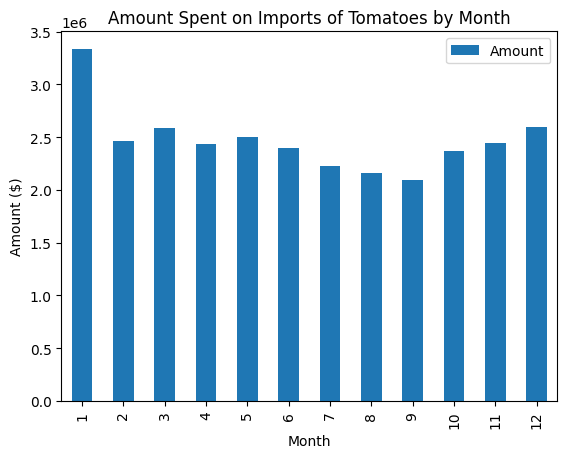

In [ ]:
# For this same commodity (Tomatoes), take a look at the imports made by MonthNumber. Plot a bar graph to see how much was spent on imports every month of the year. Does this match what you could expect?

# group the import data by MonthNumber so the aggregated dollar Amount will be a sum for each of the twelve months across all the years of data
# filter for Tomatoes only
is_tomatoes = df_dollars_by_country['CommodityName'] == 'Tomatoes'
df_tomatoes_by_month = (
    df_dollars_by_country[is_tomatoes]
    .groupby(
      ["MonthNumber"])
      ['Amount']
      .sum()
)
# Make sure the data is sorted by month before graphing
df_tomatoes_by_month = df_tomatoes_by_month.reset_index()
df_tomatoes_by_month = df_tomatoes_by_month.sort_values(["MonthNumber"])
print(df_tomatoes_by_month) # raw data sorted by month
print(df_tomatoes_by_month.sort_values('Amount', ascending = False)) # raw data sorted by Amount descending
bar_graph = df_tomatoes_by_month.plot(x='MonthNumber', y='Amount', kind='bar')
bar_graph.set_xlabel("Month")
bar_graph.set_ylabel("Amount ($)")
bar_graph.set_title("Amount Spent on Imports of Tomatoes by Month")
print ("This graph shows import spending on tomatoes is higher in winter months (December–January) and lower in summer months (July–September)." + "\n" + "This matches what I would expect, since tomatoes are out of season domestically in winter and more available locally in summer (less need to import them)." )

This many Unit,Trade rows were filtered out: -542247
This many World rows were filtered out: -18384
    MonthNumber        Amount
0             1  4.815504e+06
1             2  3.881006e+06
2             3  4.285657e+06
3             4  4.023164e+06
4             5  3.991614e+06
5             6  3.817242e+06
6             7  3.403773e+06
7             8  3.281194e+06
8             9  3.169532e+06
9            10  3.573191e+06
10           11  3.575793e+06
11           12  3.665626e+06
    MonthNumber        Amount
0             1  4.815504e+06
2             3  4.285657e+06
3             4  4.023164e+06
4             5  3.991614e+06
1             2  3.881006e+06
5             6  3.817242e+06
11           12  3.665626e+06
10           11  3.575793e+06
9            10  3.573191e+06
6             7  3.403773e+06
7             8  3.281194e+06
8             9  3.169532e+06
This graph shows that pounds of tomatoes imported are highest in January and generally lower in the summer months (July–

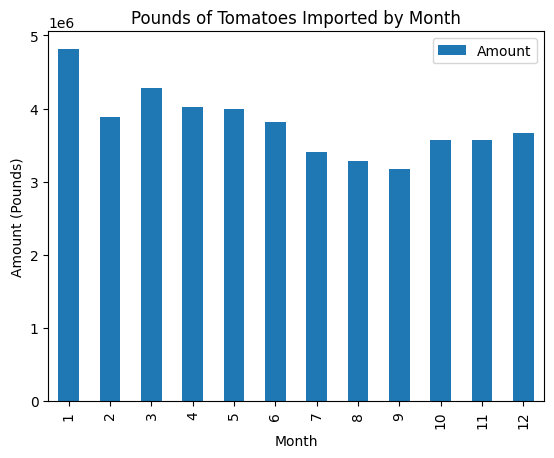

In [ ]:
# We can see if monthly differences are due to lack of US supply or a price increase. Plot the same graph as above, but for Thousand pounds and not Thousand dollars (hint: you'll need to repeat some steps done above, specifically in the the cleaning and filtering section). Doing a visual analysis of the two bar graphs, does the US spend more on imports of the top commodity due to an increase in demand or an increase in price?

# Clean and filter the data

# Filter to only keep rows that deal in Thousand pounds and only the rows specific to Imports.
row_count_before = len(df)

is_pounds = (df["UnitDesc"] == "Thousand pounds") #filter for pounds
is_import = (df["Trade"] == "Import")

df_imports_in_pounds = df[is_pounds & is_import]
# df_imports_in_pounds = df[(df["UnitDesc"] == "Thousand pounds") & (df["Trade"] == "Import")]

row_count_after = len(df_imports_in_pounds)
print("This many Unit,Trade rows were filtered out: " + str(row_count_after - row_count_before))

# Remove countries that are marked as World
row_count_before = len(df_imports_in_pounds)

# Use a filter to create a "subset" DataFrame containing all of the rows from the df_imports_in_pounds where the GeographicDesc column has any value except "World"
is_not_World = (df_imports_in_pounds['GeographicDesc'] != "World")
df_pounds_by_country = df_imports_in_pounds[is_not_World]

# df_pounds_by_country = df_imports_in_pounds[(df_imports_in_pounds['GeographicDesc'] != "World")]

row_count_after = len(df_pounds_by_country)
print("This many World rows were filtered out: " + str(row_count_after - row_count_before))

# group the import data by MonthNumber so the aggregated pounds Amount will be a sum for each of the twelve months across all the years of data
# filter for Tomatoes only
is_tomatoes = df_pounds_by_country['CommodityName'] == 'Tomatoes'
df_tomatoes_by_month_in_pounds = (
    df_pounds_by_country[is_tomatoes]
    .groupby(
      ["MonthNumber"])
      ['Amount']
      .sum()
)
# Make sure the data is sorted by month before graphing
df_tomatoes_by_month_in_pounds = df_tomatoes_by_month_in_pounds.reset_index()
df_tomatoes_by_month_in_pounds = df_tomatoes_by_month_in_pounds.sort_values(["MonthNumber"])
print(df_tomatoes_by_month_in_pounds) # raw data sorted by month
print(df_tomatoes_by_month_in_pounds.sort_values('Amount', ascending = False)) # raw data sorted by Amount descending
bar_graph = df_tomatoes_by_month_in_pounds.plot(x='MonthNumber', y='Amount', kind='bar')
bar_graph.set_xlabel("Month")
bar_graph.set_ylabel("Amount (Pounds)")
bar_graph.set_title("Pounds of Tomatoes Imported by Month")
print ("This graph shows that pounds of tomatoes imported are highest in January and generally lower in the summer months (July–September)." + "\n" + "Comparing this graph to the dollar graph, the overall seasonal pattern is similar, but not identical." + "\n" + "In particular, December looks relatively higher in dollars than it does in pounds." + "\n" + "That suggests the higher spending is not just due to importing more tomatoes, and higher prices may be playing a role in some months (e.g. October - December)." )